In [5]:
import sys
print(sys.executable)
import pickle

# All of the imports that are going to be used throughout the model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import joblib

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

/home/codespace/.python/current/bin/python


In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/Mik-Nowak-05/Alzheimers_Disease_Prediction_Model/refs/heads/main/alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [7]:
df.shape

(2149, 35)

In [8]:
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1) # Dropping the Columns that have IDs or Data that is unpredictable
df.shape

(2149, 33)

In [9]:
df.head(10)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0
5,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,7.261953,...,5.510144,0,0,9.015686,1,0,0,0,0,0
6,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,5.477686,...,6.062124,0,0,9.236328,0,0,0,0,1,0
7,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,4.213210,...,3.401374,0,0,4.517248,1,0,0,0,1,1
8,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,5.748224,...,7.396061,0,1,0.756232,0,0,1,0,0,0
9,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,7.551773,...,1.148904,0,1,4.554394,0,0,0,0,0,0


In [10]:
cat_df = df.select_dtypes(include=[object]) # Checking whether categorical columns exist inside the data frame
cat_df.describe

<bound method NDFrame.describe of Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[2149 rows x 0 columns]>

In [11]:
z_scores = np.abs(stats.zscore(df, nan_policy='omit')) # Calculating the z-scores

z_scores_df = pd.DataFrame(z_scores, columns=df.columns, index=df.index) # Converting back to the DataFrame so that we can use it later
z_mean_per_row = z_scores_df.mean(axis=1) # Mean z-score per row

z_mean_per_row.describe()

count    2149.000000
mean        0.829316
std         0.096439
min         0.538495
25%         0.760568
50%         0.824161
75%         0.892383
max         1.174333
dtype: float64

In [12]:
Q1 = z_scores_df.quantile(0.25) # Compute the lower Q1
Q3 = z_scores_df.quantile(0.75) # Computer the upper Q3
IQR = Q3 - Q1 # Calculate the IQR, as we will need that for outlier boundaries

lower_bound = Q1 - 1.5 * IQR # Defining lower bound for outlier
upper_bound = Q3 + 1.5 * IQR # Defining upper bound for outlier

outliers = (z_scores_df < lower_bound) | (z_scores_df > upper_bound) # Identifying outlier cells per column based on the above bounds

outlier_fraction = outliers.mean(axis=1) # Calculating fractions of the outlier values for each row

df_outliers = df[outlier_fraction >= 0.5] # Dropping rows that are >= 50% filled with outliers

In [13]:
df_outliers.shape # No outliers inside the dataset that would fill the threshold of 50%

(0, 33)

In [14]:
corr = df.corr(numeric_only=True)['Diagnosis'].sort_values(ascending=False) # Computing the correlations with the target variable,
                                                                                            # i.e. Diagnosis for better insight
print(corr)

Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes                    -0.031508
CholesterolL

In [15]:
# Splitting data into train and test
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
 
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
 
y_train = df_train.Diagnosis.values
y_val = df_val.Diagnosis.values
y_test = df_test.Diagnosis.values
 
del df_train['Diagnosis']
del df_val['Diagnosis']
del df_test['Diagnosis'] 


In [16]:
# Scale features
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train)
df_val_scaled = scaler.transform(df_val)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(df_train_scaled, y_train)

# Predict
# probability that Diagnosis = 1
y_pred = model.predict_proba(df_val_scaled)[:, 1]
alz_prediction = (y_pred >= 0.5)

# Accuracy
(y_val == alz_prediction).mean()

np.float64(0.8395348837209302)

In [17]:
# Accuracy and Dummy model
len(y_val)
(y_val == alz_prediction).sum()
(y_val == alz_prediction).mean()


np.float64(0.8395348837209302)

In [18]:
# Evaluate the model on different thresholds
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [19]:
thresholds = np.linspace(0, 1, 21)
scores = []
 
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.363
0.05 0.616
0.10 0.716
0.15 0.749
0.20 0.767
0.25 0.805
0.30 0.823
0.35 0.830
0.40 0.851
0.45 0.844
0.50 0.840
0.55 0.844
0.60 0.847
0.65 0.835
0.70 0.826
0.75 0.791
0.80 0.774
0.85 0.753
0.90 0.721
0.95 0.695
1.00 0.637


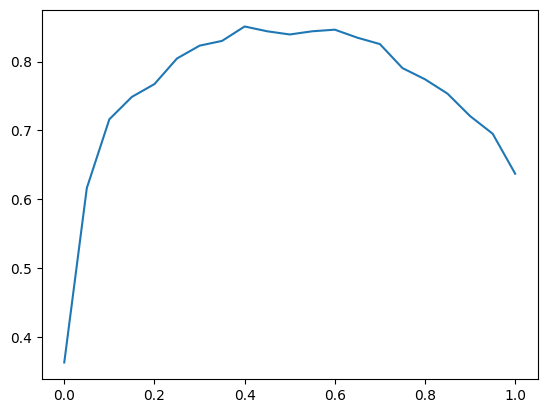

In [20]:
# threshold of 0.55 gives accuracy of 0.849
plt.plot(thresholds,scores)

In [21]:
# people who will develop Alzheimer's
actual_positive = (y_val == 1)
# people who will not develop Alzheimer's
actual_negative = (y_val == 0)

t = 0.55
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [22]:
predict_positive & actual_positive
 
tp = (predict_positive & actual_positive).sum()
tp

tn = (predict_negative & actual_negative).sum()
tn
 
fp = (predict_positive & actual_negative).sum()
fp

fn = (predict_negative & actual_positive).sum()
fn


np.int64(51)

In [23]:
auc = roc_auc_score(y_val, y_pred)
print("AUC-ROC:", auc)

AUC-ROC: 0.9099288789069812


In [24]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=500),
        {"C": [0.1, 1, 10]}
    ),

    "DecisionTree": (
        DecisionTreeClassifier(),
        {"max_depth": [3, 5, 10], "min_samples_leaf": [1, 5, 10]}
    ),

    "RandomForest": (
        RandomForestClassifier(),
        {"n_estimators": [100, 300],
         "max_depth": [None, 10, 20]}
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {"n_estimators": [100, 200],
         "learning_rate": [0.05, 0.1]}
    ),
}


In [25]:
# Cross-validation evaluation helper
def evaluate_with_cv(model, X, y):
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    return scores.mean(), scores.std()


In [26]:
# Hyperparameter tuning with GridSearchCV
summary_rows = []

for name, (model, param_grid) in models.items():

    print(f"🔍 Tuning {name}...")

    # Pipeline with scaling (tree models ignore the scaler)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(pipe, param_grid={"model__" + k: v for k, v in param_grid.items()},
                        cv=5, scoring="roc_auc", n_jobs=-1)

    grid.fit(df_train, y_train)

    best_model = grid.best_estimator_
    mean_score, std_score = evaluate_with_cv(best_model, df_train, y_train)

    summary_rows.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV Mean AUC": mean_score,
        "CV Std": std_score,
    })


🔍 Tuning LogisticRegression...
🔍 Tuning DecisionTree...
🔍 Tuning RandomForest...
🔍 Tuning GradientBoosting...


In [27]:
# Summary results table 
df_results = pd.DataFrame(summary_rows)
print(df_results.sort_values("CV Mean AUC", ascending=False))


                Model                                        Best Params  \
2        RandomForest  {'model__max_depth': 20, 'model__n_estimators'...   
3    GradientBoosting  {'model__learning_rate': 0.05, 'model__n_estim...   
1        DecisionTree  {'model__max_depth': 10, 'model__min_samples_l...   
0  LogisticRegression                                  {'model__C': 0.1}   

   CV Mean AUC    CV Std  
2     0.949015  0.009623  
3     0.944783  0.006318  
1     0.939130  0.014083  
0     0.891460  0.006031  


In [28]:
df_sorted = df_results.sort_values("CV Mean AUC", ascending=False)
print(df_sorted.iloc[0])



Model                                               RandomForest
Best Params    {'model__max_depth': 20, 'model__n_estimators'...
CV Mean AUC                                             0.949015
CV Std                                                  0.009623
Name: 2, dtype: object


In [29]:
# Trying out the Random Forest Classifier
random_forest = RandomForestClassifier(random_state=42)

random_forest.fit(df_train, y_train)

y_pred = random_forest.predict(df_test)

# Testing the Predictions
print("----------------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("----------------------------------------------------------")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n----------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("----------------------------------------------------------")

----------------------------------------------------------
Accuracy: 0.9162790697674419
Precision: 0.9606299212598425
Recall: 0.7973856209150327
F1 Score: 0.8714285714285714
----------------------------------------------------------

Confusion Matrix:
 [[272   5]
 [ 31 122]]

----------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.96      0.80      0.87       153

    accuracy                           0.92       430
   macro avg       0.93      0.89      0.90       430
weighted avg       0.92      0.92      0.91       430

----------------------------------------------------------


In [30]:
# Realised that the scores are great, apart from the Recall which I would like to be higher
# Using RandomizedSearchCV to fine-tune the Random Forest Classifier
params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2', 0.5, None],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

random_forest_cv = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=params,
    n_iter=50,
    scoring='recall', # Optimising the Recall
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_forest_cv.fit(df_train, y_train)

# Checking the best parameters:
print("----------------------------------------------------------")
print("Best Recall Score (CV):", random_forest_cv.best_score_)
print("----------------------------------------------------------")
print("\nBest Parameters:\n", random_forest_cv.best_params_)
print("----------------------------------------------------------")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=5, max_features=0.5, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=5, max_features=0.5, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=5, max_features=0.5, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=5, max_features=0.5, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.8s
[CV] END bootstrap=True, class_weight=None, max_depth=5, max_features=0.5, min_samples_leaf=5, min_samples_split=6, n_estimators=100; total time=   0.6s
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=5, max_features=0.5, min_samples_leaf=2,

In [ ]:
# Trying the Fine-tuned Random Forest Classifier
random_forest_tuned = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=3,
    max_features=None,
    max_depth=10,
    class_weight='balanced',
    bootstrap=True,
    random_state=42
)

random_forest_tuned.fit(df_train, y_train)

y_pred = random_forest_tuned.predict(df_test)

# Testing the Predictions
print("----------------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("----------------------------------------------------------")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n----------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("----------------------------------------------------------")

----------------------------------------------------------
Accuracy: 0.9465116279069767
Precision: 0.9577464788732394
Recall: 0.8888888888888888
F1 Score: 0.9220338983050848
----------------------------------------------------------

Confusion Matrix:
 [[271   6]
 [ 17 136]]

----------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       277
           1       0.96      0.89      0.92       153

    accuracy                           0.95       430
   macro avg       0.95      0.93      0.94       430
weighted avg       0.95      0.95      0.95       430

----------------------------------------------------------


In [32]:
# Joblib for Usage in Production
joblib.dump(random_forest_tuned, "random_forest_model_tuned.pkl") # Saving the fine-tuned model for production (Overall Accuracy of ~96%)

['random_forest_model_tuned.pkl']

In [45]:
# save the model to pickle
output_file = 'random_forest_tuned' 

f_out = open(output_file, 'wb') 
pickle.dump((model), f_out)
output_file
f_out.close()

